In [2]:
import sys
import pandas as pd
import numpy as np
from PyQt5 import QtWidgets
from sklearn.preprocessing import LabelEncoder

# 향수 데이터 로드 및 전처리
def load_and_prepare_data():
    data = pd.read_csv("C:/PerfumeS/spm/preprocessing_perfumes_dataset1.csv", encoding='cp949')
    
    le_dict = {}
    for column in ['department', 'scents', 'concentration']:
        le_dict[column] = LabelEncoder()
        data[column] = le_dict[column].fit_transform(data[column])

    data['base_note_split'] = data['base_note'].str.split(', ')
    data_exploded = data.explode('base_note_split').reset_index(drop=True)
    le_dict['base_note_split'] = LabelEncoder()
    data_exploded['base_note_split'] = le_dict['base_note_split'].fit_transform(data_exploded['base_note_split'])

    data_exploded = data_exploded.drop_duplicates(subset=['name', 'department', 'scents', 'base_note_split', 'concentration'])
    
    return data_exploded, le_dict

# 데이터 전처리 후 결과 시각화
def visualize_data(data_exploded):
    # 데이터의 상위 5개 행을 출력
    print("Data Sample:")
    print(data_exploded.head())

    # 데이터 컬럼별 정보 요약
    print("\nData Info:")
    print(data_exploded.info())

    # 데이터 컬럼별 고유값 개수 확인
    print("\nUnique Values in Each Column:")
    for column in data_exploded.columns:
        print(f"{column}: {data_exploded[column].nunique()} unique values")

if __name__ == '__main__':
    data_exploded, le_dict = load_and_prepare_data()
    visualize_data(data_exploded)


Data Sample:
   Unnamed: 0            brand               name  new_price   ml  \
0           0     PACO RABANNE    1 Million Lucky     244.55  100   
1           0     PACO RABANNE    1 Million Lucky     244.55  100   
2           1  Roberto Cavalli  Paradiso Assoluto     107.95   50   
3           1  Roberto Cavalli  Paradiso Assoluto     107.95   50   
4           2       S.T.Dupont        Royal Amber     186.90  100   

   concentration  department  scents                          base_note  \
0              2           0      18     Oakmoss, Patchouli and Vetiver   
1              2           0      18     Oakmoss, Patchouli and Vetiver   
2              1           2       5  Vanilla, Sandalwood And Patchouli   
3              1           2       5  Vanilla, Sandalwood And Patchouli   
4              1           1       0          Lemon, Mint and Wood Moss   

                                        middle_note  item_rating  \
0  Hazelnut, Jasmine, Cashmir Wood, Cedar and Honey  

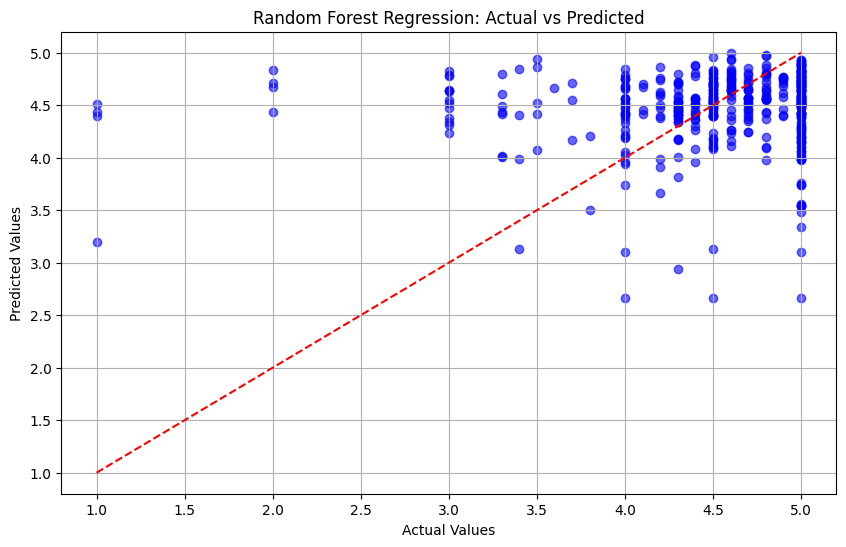

In [4]:
import sys
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PyQt5 import QtWidgets, QtCore
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import time

# 모델 경로 설정 (YOLOv8)
model_path = "C:/PerfumeS/spm/runs/detect/train3/weights/best.pt"
model = YOLO(model_path)

# 향수 데이터 로드 및 전처리
def load_and_prepare_data():
    data = pd.read_csv("C:/PerfumeS/spm/preprocessing_perfumes_dataset1.csv", encoding='cp949')
    
    le_dict = {}
    for column in ['department', 'scents', 'concentration']:
        le_dict[column] = LabelEncoder()
        data[column] = le_dict[column].fit_transform(data[column])

    data['base_note_split'] = data['base_note'].str.split(', ')
    data_exploded = data.explode('base_note_split').reset_index(drop=True)
    le_dict['base_note_split'] = LabelEncoder()
    data_exploded['base_note_split'] = le_dict['base_note_split'].fit_transform(data_exploded['base_note_split'])

    data_exploded = data_exploded.drop_duplicates(subset=['name', 'department', 'scents', 'base_note_split', 'concentration'])
    
    return data_exploded, le_dict

# 랜덤포레스트 회귀 모델 정의 및 학습
def train_random_forest(data_exploded):
    # 특성과 타겟 변수 정의
    X = data_exploded[['department', 'scents', 'base_note_split', 'concentration']]
    y = data_exploded['item_rating']

    # 학습 데이터와 테스트 데이터로 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 랜덤포레스트 모델 학습
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    return rf_model, X_test, y_test

# 예측 및 결과 시각화
def visualize_random_forest_results(rf_model, X_test, y_test):
    # 예측값 계산
    y_pred = rf_model.predict(X_test)

    # 결과 시각화
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # y=x 라인
    plt.title('Random Forest Regression: Actual vs Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)
    plt.show()

# 전체 실행
if __name__ == '__main__':
    data_exploded, le_dict = load_and_prepare_data()
    rf_model, X_test, y_test = train_random_forest(data_exploded)
    visualize_random_forest_results(rf_model, X_test, y_test)


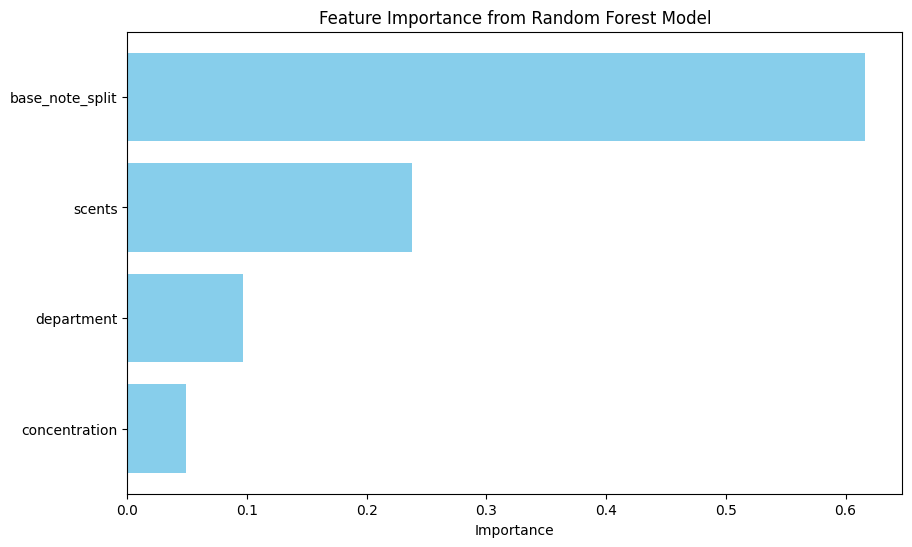

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# 랜덤포레스트 회귀 모델 학습 후 특징 중요도 시각화
def visualize_feature_importance(rf_model, data_exploded, le_dict):
    # 특징 이름 추출
    feature_names = data_exploded[['department', 'scents', 'base_note_split', 'concentration']].columns

    # 특징 중요도 추출
    importances = rf_model.feature_importances_

    # 데이터프레임으로 변환
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

    # 중요도 기준으로 정렬
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    # 바 차트로 시각화
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
    plt.xlabel('Importance')
    plt.title('Feature Importance from Random Forest Model')
    plt.gca().invert_yaxis()  # 가장 중요한 특징을 위에 표시
    plt.show()

# 사용 예시
if __name__ == '__main__':
    data_exploded, le_dict = load_and_prepare_data()
    rf_model, X_test, y_test = train_random_forest(data_exploded)
    visualize_feature_importance(rf_model, data_exploded, le_dict)


c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  

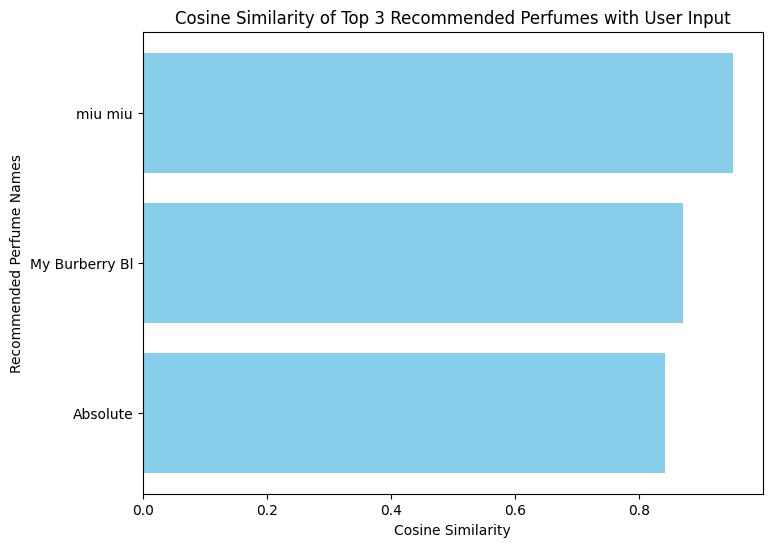

In [7]:
import matplotlib.pyplot as plt

# 추천된 세 가지 향수를 얻기 위한 사용자 입력 처리
user_gender = 'Men'
user_preferred_scent = 'Floral'
user_situation = 'everyday'
user_mood = 'happy'

gender_encoded = le_dict['department'].transform([user_gender])[0]
scent_encoded = le_dict['scents'].transform([user_preferred_scent])[0]
mood_scents = {
    'happy': ['Floral', 'Fruity', 'Citrus']
}.get(user_mood, [])

mood_encoded = [le_dict['scents'].transform([s])[0] for s in mood_scents if s in le_dict['scents'].classes_]
mood_avg = np.mean(mood_encoded) if mood_encoded else 0

situation_concentration_mapping = {
    'everyday': ['EDT', 'EDC']
}

situation_encoded = [le_dict['concentration'].transform([c])[0] for c in situation_concentration_mapping[user_situation]]
situation_avg = np.mean(situation_encoded) if situation_encoded else 0

user_vector = np.array([gender_encoded, scent_encoded, mood_avg, situation_avg])

# 코사인 유사도 및 최종 점수 계산
similarity_scores = []

for name, group in data_exploded.groupby('name'):
    perfume_vector = np.array([group['department'].iloc[0], group['scents'].iloc[0], group['base_note_split'].mean(), group['concentration'].iloc[0]])
    similarity = cosine_similarity(user_vector.reshape(1, -1), perfume_vector.reshape(1, -1))[0][0]

    predicted_rating = rf_model.predict(perfume_vector.reshape(1, -1))[0]
    final_score = similarity * 0.7 + predicted_rating * 0.3

    if group['item_rating'].iloc[0] >= 3.5:
        similarity_scores.append((name, final_score, similarity, group.iloc[0]))

# 상위 세 가지 향수 선택
recommended_perfumes = sorted(similarity_scores, key=lambda x: x[1], reverse=True)[:3]

# 추천된 세 향수에 대한 코사인 유사도 시각화
perfume_names = [perfume[0] for perfume in recommended_perfumes]
cosine_similarities = [perfume[2] for perfume in recommended_perfumes]

plt.figure(figsize=(8, 6))
plt.barh(perfume_names, cosine_similarities, color='skyblue')
plt.xlabel('Cosine Similarity')
plt.ylabel('Recommended Perfume Names')
plt.title('Cosine Similarity of Top 3 Recommended Perfumes with User Input')
plt.gca().invert_yaxis()
plt.show()


c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  

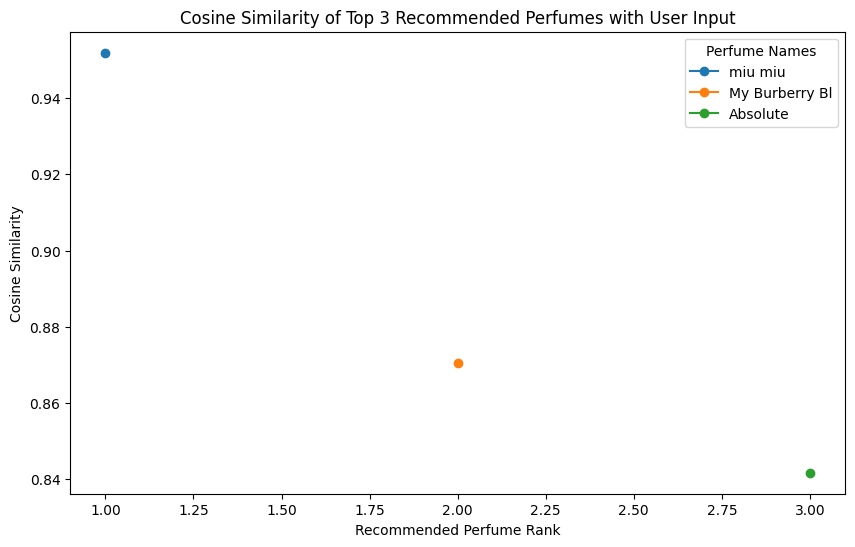

In [8]:
import matplotlib.pyplot as plt

# 추천된 세 가지 향수를 얻기 위한 사용자 입력 처리
user_gender = 'Men'
user_preferred_scent = 'Floral'
user_situation = 'everyday'
user_mood = 'happy'

gender_encoded = le_dict['department'].transform([user_gender])[0]
scent_encoded = le_dict['scents'].transform([user_preferred_scent])[0]
mood_scents = {
    'happy': ['Floral', 'Fruity', 'Citrus']
}.get(user_mood, [])

mood_encoded = [le_dict['scents'].transform([s])[0] for s in mood_scents if s in le_dict['scents'].classes_]
mood_avg = np.mean(mood_encoded) if mood_encoded else 0

situation_concentration_mapping = {
    'everyday': ['EDT', 'EDC']
}

situation_encoded = [le_dict['concentration'].transform([c])[0] for c in situation_concentration_mapping[user_situation]]
situation_avg = np.mean(situation_encoded) if situation_encoded else 0

user_vector = np.array([gender_encoded, scent_encoded, mood_avg, situation_avg])

# 코사인 유사도 및 최종 점수 계산
similarity_scores = []

for name, group in data_exploded.groupby('name'):
    perfume_vector = np.array([group['department'].iloc[0], group['scents'].iloc[0], group['base_note_split'].mean(), group['concentration'].iloc[0]])
    similarity = cosine_similarity(user_vector.reshape(1, -1), perfume_vector.reshape(1, -1))[0][0]

    predicted_rating = rf_model.predict(perfume_vector.reshape(1, -1))[0]
    final_score = similarity * 0.7 + predicted_rating * 0.3

    if group['item_rating'].iloc[0] >= 3.5:
        similarity_scores.append((name, final_score, similarity, group.iloc[0]))

# 상위 세 가지 향수 선택
recommended_perfumes = sorted(similarity_scores, key=lambda x: x[1], reverse=True)[:3]

# 그래프 그리기 위한 데이터 추출
perfume_names = [perfume[0] for perfume in recommended_perfumes]
cosine_similarities = [perfume[2] for perfume in recommended_perfumes]

# 코사인 유사도 선 그래프 생성
plt.figure(figsize=(10, 6))
for i, perfume_name in enumerate(perfume_names):
    plt.plot([i + 1], [cosine_similarities[i]], marker='o', label=perfume_name)

# 그래프 스타일 설정
plt.xlabel('Recommended Perfume Rank')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity of Top 3 Recommended Perfumes with User Input')
plt.legend(title="Perfume Names")
plt.show()


c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\Perfume_rec\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  

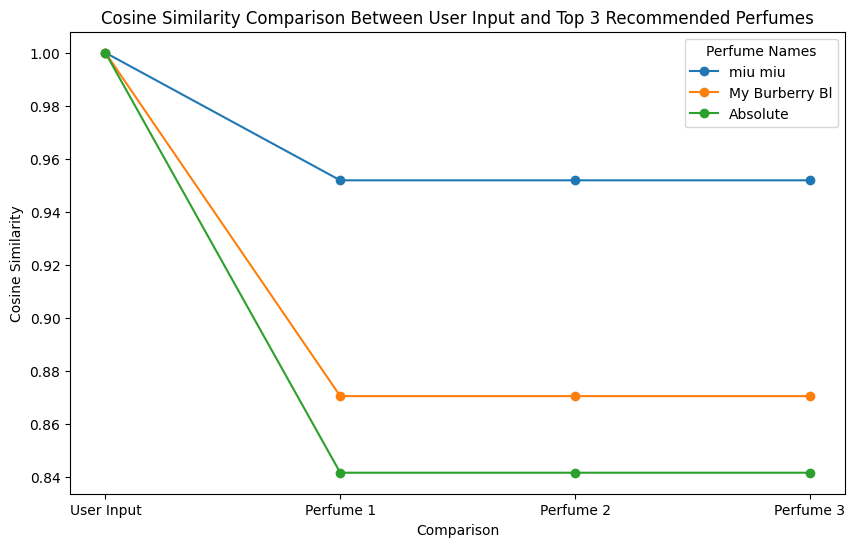

In [9]:
import matplotlib.pyplot as plt

# 추천된 세 가지 향수를 얻기 위한 사용자 입력 처리
user_gender = 'Men'
user_preferred_scent = 'Floral'
user_situation = 'everyday'
user_mood = 'happy'

gender_encoded = le_dict['department'].transform([user_gender])[0]
scent_encoded = le_dict['scents'].transform([user_preferred_scent])[0]
mood_scents = {
    'happy': ['Floral', 'Fruity', 'Citrus']
}.get(user_mood, [])

mood_encoded = [le_dict['scents'].transform([s])[0] for s in mood_scents if s in le_dict['scents'].classes_]
mood_avg = np.mean(mood_encoded) if mood_encoded else 0

situation_concentration_mapping = {
    'everyday': ['EDT', 'EDC']
}

situation_encoded = [le_dict['concentration'].transform([c])[0] for c in situation_concentration_mapping[user_situation]]
situation_avg = np.mean(situation_encoded) if situation_encoded else 0

user_vector = np.array([gender_encoded, scent_encoded, mood_avg, situation_avg])

# 코사인 유사도 및 최종 점수 계산
similarity_scores = []

for name, group in data_exploded.groupby('name'):
    perfume_vector = np.array([group['department'].iloc[0], group['scents'].iloc[0], group['base_note_split'].mean(), group['concentration'].iloc[0]])
    similarity = cosine_similarity(user_vector.reshape(1, -1), perfume_vector.reshape(1, -1))[0][0]

    predicted_rating = rf_model.predict(perfume_vector.reshape(1, -1))[0]
    final_score = similarity * 0.7 + predicted_rating * 0.3

    if group['item_rating'].iloc[0] >= 3.5:
        similarity_scores.append((name, final_score, similarity, group.iloc[0]))

# 상위 세 가지 향수 선택
recommended_perfumes = sorted(similarity_scores, key=lambda x: x[1], reverse=True)[:3]

# 그래프 그리기 위한 데이터 추출
perfume_names = [perfume[0] for perfume in recommended_perfumes]
cosine_similarities = [perfume[2] for perfume in recommended_perfumes]

# 사용자와 추천 향수의 코사인 유사도 비교 선 그래프 생성
plt.figure(figsize=(10, 6))
x_labels = ["User Input", "Perfume 1", "Perfume 2", "Perfume 3"]

# 사용자 입력에 대한 코사인 유사도는 항상 1로 설정
user_similarity = 1.0

# 각 추천 향수에 대해 선을 그립니다
for i, perfume_name in enumerate(perfume_names):
    plt.plot(x_labels, [user_similarity, cosine_similarities[i], cosine_similarities[i], cosine_similarities[i]],
             marker='o', label=f'{perfume_name}')

# 그래프 스타일 설정
plt.xlabel('Comparison')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity Comparison Between User Input and Top 3 Recommended Perfumes')
plt.legend(title="Perfume Names")
plt.show()


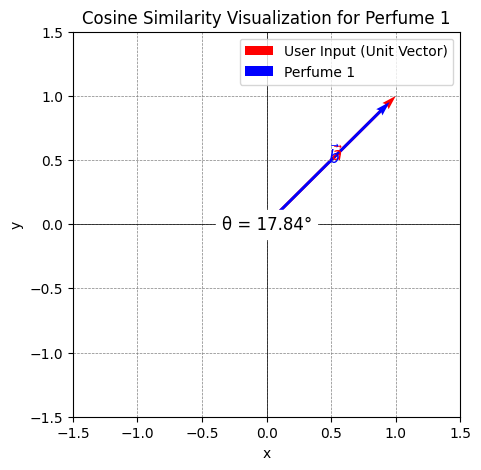

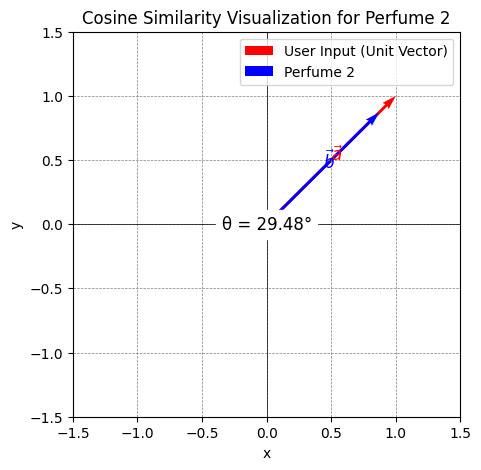

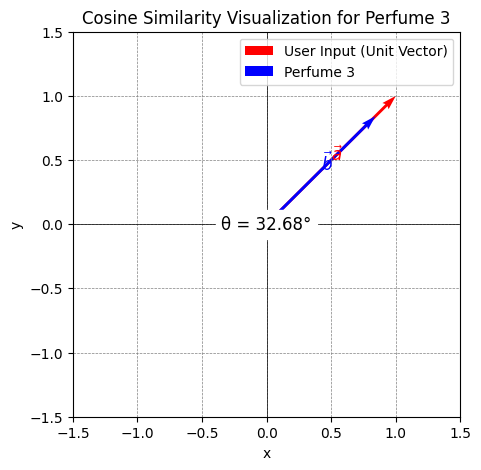

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 사용자 입력 벡터와 추천된 향수 벡터들
user_vector = np.array([1, 1])  # 사용자 입력 벡터를 단위 벡터로 표시

# 추천 향수 코사인 유사도에 따라 벡터 계산
recommended_cosine_similarities = cosine_similarities  # 추천된 세 향수의 코사인 유사도
recommended_vectors = [cos_sim * user_vector for cos_sim in recommended_cosine_similarities]

# 시각화
for i, perfume_vector in enumerate(recommended_vectors):
    plt.figure(figsize=(5, 5))

    # 사용자 벡터와 추천 벡터를 플롯
    plt.quiver(0, 0, user_vector[0], user_vector[1], angles='xy', scale_units='xy', scale=1, color='r', label="User Input (Unit Vector)")
    plt.quiver(0, 0, perfume_vector[0], perfume_vector[1], angles='xy', scale_units='xy', scale=1, color='b', label=f"Perfume {i + 1}")

    # 각도 및 텍스트 표시
    theta = np.arccos(recommended_cosine_similarities[i])  # 벡터 사이의 각도
    theta_degrees = np.degrees(theta)
    plt.text(0.5 * user_vector[0], 0.5 * user_vector[1], r'$\vec{a}$', fontsize=12, color='red')
    plt.text(0.5 * perfume_vector[0], 0.5 * perfume_vector[1], r'$\vec{b}$', fontsize=12, color='blue')
    plt.text(0, 0, f"θ = {theta_degrees:.2f}°", fontsize=12, ha='center', va='center', backgroundcolor='white')

    # 축 설정
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)
    plt.axhline(0, color='black',linewidth=0.5)
    plt.axvline(0, color='black',linewidth=0.5)
    plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Cosine Similarity Visualization for Perfume {i + 1}')
    plt.legend()
    plt.show()
